In [2]:
import pandas as pd

/tmp/ipykernel_479657/4080736814.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
# seed3つの平均スコアを計算する関数
def get_avg_score(df):
    df["model"] = df["name"].str.replace(r"_seed\d+", "", regex=True)
    df_avg=df.groupby("model").mean(numeric_only=True).reset_index()
    return df_avg

In [4]:
# mlpのparamsを計算する関数
def mlp_params(input_dim,output_dim):
    # hidden size 1024, layers 2
    hidden_size = 1024
    layer1 = (input_dim * hidden_size) + hidden_size
    layer2 = (hidden_size * hidden_size) + hidden_size
    layer3 = (hidden_size * output_dim) + output_dim
    params = layer1 + layer2 + layer3
    return params

# rnnのparamsを計算する関数
def rnn_params(input_dim,output_dim):
    # hidden size 400, layers 2, LSTM Cell
    hidden_size = 400
    layer1 = 4 * ((input_dim + hidden_size) * hidden_size + hidden_size)
    layer2 = 4 * ((hidden_size + hidden_size) * hidden_size + hidden_size)
    layer3 = (hidden_size * output_dim) + output_dim
    params = layer1 + layer2 + layer3
    return params

# ncpのparamsを計算する関数
def ncp_params(input_dim, output_dim, units):
    layer1 = (input_dim * units) + units
    params_1 = units * 3 #gleak,vleak,cm
    params_2 = units * units * 5 # sigma, mu, w, erev, sparsity_mask
    params_3 = input_dim * units * 5 # sensory_sigma, sensory_mu, sensory_w, sensory_erev, sensory_sparsity_mask
    layer2 = (units * output_dim) + output_dim
    params = layer1 + params_1 + params_2 + params_3 + layer2
    return params

In [5]:
# MACsを計算する関数
# MLPの場合
def mlp_macs(input_dim, hidden_dim, output_dim):
    macs=(input_dim * hidden_dim + hidden_dim) + (hidden_dim * hidden_dim + hidden_dim) + (hidden_dim * output_dim + output_dim)
    nlops = hidden_dim * 2 + output_dim
    return macs

# RNNの場合
def rnn_macs(input_dim: int, hidden_dim: int, num_layers: int, output_dim: int = 0):
    # 1層目の入力は input_dim、以降の層の入力は hidden_dim
    macs_input_layer = 4 * (input_dim * hidden_dim + hidden_dim * hidden_dim + hidden_dim)  # +bias
    macs_deeper_layer = 4 * (hidden_dim * hidden_dim + hidden_dim * hidden_dim + hidden_dim)
    macs_lstm_all_layers = macs_input_layer + (num_layers - 1) * macs_deeper_layer

    macs_output = 0
    if output_dim and output_dim > 0:
        macs_output = hidden_dim * output_dim + output_dim  # +bias

    macs_per_step = macs_lstm_all_layers + macs_output

    return macs_per_step

# NCPの場合
def ncp_macs(input_dim: int, units: int, output_dim: int, ode_unfolds: int, k_nl: int = 1):
    macs_core_per_unfold = (units * units) * 2 + 4
    nlops_core_per_unfold = units * units

    macs_per_step = ode_unfolds * macs_core_per_unfold * units
    nlops_per_step = ode_unfolds * (nlops_core_per_unfold + units) + input_dim

    return macs_per_step

In [6]:
import re
def calculate_model_size(df, task):
    df = df.copy()
    if task == "lift": #[10,3,4,2]
        input_dim = 19
        output_dim = 7
    elif task == "can": #[14,3,4,2]
        input_dim = 23
        output_dim = 7
    elif task == "square": #[14,3,4,2]
        input_dim = 23
        output_dim = 7
    else:
        raise ValueError("Unknown task")
    for model in df["model"].unique():
        idx = df["model"] == model
        if model == "bc-pure":
            df.loc[idx, "params"] = mlp_params(input_dim, output_dim)
        elif model == "bc-rnn-pure":
            df.loc[idx, "params"] = rnn_params(input_dim, output_dim)
        elif model.startswith("ncp"):
            u = int(re.search(r"_u(\d+)", model).group(1))
            df.loc[idx, "params"] = ncp_params(input_dim, output_dim, u)
        else:
            raise ValueError("Unknown model")
    return df

def calculate_macs_size(df, task):
    df = df.copy()
    if task == "lift": #[10,3,4,2]
        input_dim = 19
        output_dim = 7
    elif task == "can": #[14,3,4,2]
        input_dim = 23
        output_dim = 7
    elif task == "square": #[14,3,4,2]
        input_dim = 23
        output_dim = 7
    else:
        raise ValueError("Unknown task")
    for model in df["model"].unique():
        idx = df["model"] == model
        if model == "bc-pure":
            df.loc[idx, "macs"] = mlp_macs(input_dim, 1024, output_dim)
        elif model == "bc-rnn-pure":
            df.loc[idx, "macs"] = rnn_macs(input_dim, 400, 2, output_dim)
        elif model.startswith("ncp"):
            u = int(re.search(r"_u(\d+)", model).group(1))
            df.loc[idx, "macs"] = ncp_macs(input_dim, u, output_dim, 3)
        else:
            raise ValueError("Unknown model")
    return df

In [7]:
df_lift=pd.read_csv('/work/robomimic/csv/lift/lift-best.csv')
df_can=pd.read_csv('/work/robomimic/csv/can/can-best.csv')
df_square=pd.read_csv('/work/robomimic/csv/square/square-best.csv')
df_can_avg=get_avg_score(df_can)
df_can_avg=calculate_model_size(df_can_avg, "can")
df_can_avg=calculate_macs_size(df_can_avg, "can")
df_lift_avg=get_avg_score(df_lift)
df_lift_avg=calculate_model_size(df_lift_avg, "lift")
df_lift_avg=calculate_macs_size(df_lift_avg, "lift")
df_square_avg=get_avg_score(df_square)
df_square_avg=calculate_model_size(df_square_avg, "square")
df_square_avg=calculate_macs_size(df_square_avg, "square")

In [8]:
print(df_square_avg[["model","macs", "params","return","avg_policy_latency_ms", "avg_gpu_memory_increase_mb"]])
print(df_lift_avg[["model","macs", "params","return","avg_policy_latency_ms", "avg_gpu_memory_increase_mb"]])

           model         macs     params    return  avg_policy_latency_ms  \
0        bc-pure    1081351.0  1081351.0  0.390000               0.875822   
1    bc-rnn-pure    1962807.0  1962807.0  0.670000               1.152379   
2  ncp_u128_best   12584448.0   100999.0  0.453333               1.355979   
3  ncp_u256_best  100666368.0   365831.0  0.600000               1.042837   
4  ncp_u512_best  805312512.0  1387015.0  0.566667               1.056882   
5   ncp_u64_best    1573632.0    30023.0  0.136667               4.558799   

   avg_gpu_memory_increase_mb  
0                   25.626953  
1                   39.490214  
2                    1.341309  
3                    4.924805  
4                   18.841797  
5                    0.400879  
           model         macs     params    return  avg_policy_latency_ms  \
0        bc-pure    1077255.0  1077255.0  0.970000               0.891192   
1    bc-rnn-pure    1956407.0  1956407.0  1.000000               1.180347   
2  nc

In [9]:
# u512を除外する
df_square_avg=df_square_avg[~df_square_avg["model"].str.contains("u512")]
df_can_avg=df_can_avg[~df_can_avg["model"].str.contains("u512")]
df_lift_avg=df_lift_avg[~df_lift_avg["model"].str.contains("u512")]

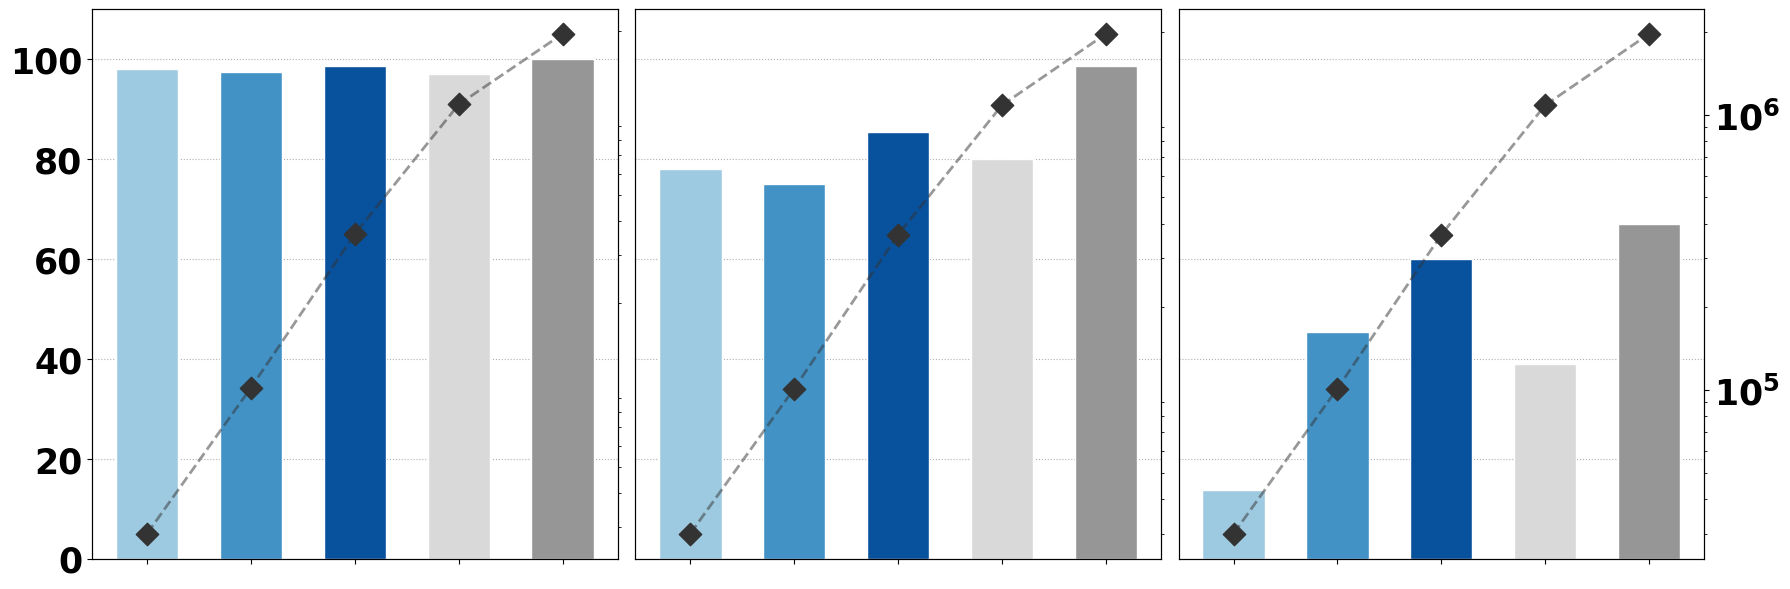

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# --- 1. スタイル設定 ---
plt.rcParams.update({
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "axes.labelsize": 25,
    "axes.titlesize": 25,
    "axes.titleweight": "bold",
    "font.weight": "bold",
    "axes.labelweight": "bold",
})

# --- 2. 色定義 ---
explicit_color = {
    "ncp_u64_best":  "#9ecae1",
    "ncp_u128_best": "#4292c6",
    "ncp_u256_best": "#08519c",
    "bc-pure":       "#d9d9d9",
    "bc-rnn-pure":   "#969696",
}
default_color = "#d9d9d9"

def get_color(model_name):
    return explicit_color.get(model_name, default_color)

# --- 3. データ ---
datasets = {
    "Lift": df_lift_avg,
    "Can": df_can_avg,
    "Square": df_square_avg
}

model_order = [
    "ncp_u64_best",
    "ncp_u128_best",
    "ncp_u256_best",
    "bc-pure",
    "bc-rnn-pure",
]

# --- 4. プロット ---
def plot_dual_axis_bar():
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, (ax1, (task_name, df)) in enumerate(zip(axes, datasets.items())):
        models = [m for m in model_order if m in df["model"].unique()]

        success_rates = []
        params = []
        colors = []

        for m in models:
            sub = df[df["model"] == m]
            success_rates.append(sub["success_rate"].mean() * 100)
            params.append(sub["params"].mean())
            colors.append(get_color(m))

        x = np.arange(len(models))

        # --- 左軸：成功率 ---
        ax1.bar(
            x, success_rates,
            width=0.6,
            color=colors,
            edgecolor="white",
            linewidth=1,
            zorder=2,
        )
        ax1.set_ylim(0, 110)
        ax1.set_xticks(x)
        ax1.set_xticklabels([""] * len(x))  # 棒の番号は表示しない

        # --- 右軸：パラメータ数 ---
        ax2 = ax1.twinx()

        ax2.plot(
            x, params,
            linestyle="--",
            linewidth=2,
            color="#333333",
            alpha=0.5,
            zorder=2,
        )
        ax2.scatter(
            x, params,
            marker="D",
            s=130,
            color="#333333",
            zorder=3,
        )

        ax2.set_yscale("log")
        ax2.yaxis.set_major_locator(ticker.LogLocator(base=10))
        ax2.yaxis.set_minor_locator(
            ticker.LogLocator(base=10, subs=np.arange(1, 10))
        )
        ax2.yaxis.set_major_formatter(
            ticker.LogFormatterMathtext(base=10)
        )
        ax1.grid(
            which="both",
            axis="y",
            linestyle=":",
            alpha=1.0,
            zorder=0
        )

        # =========================
        # 軸数字の表示制御
        # =========================

        # 左軸：一番左のみ
        if i != 0:
            ax1.set_yticklabels([])
            ax1.tick_params(axis="y", length=0)
            ax1.set_ylabel("")

        # 右軸：一番右のみ
        if i != len(axes) - 1:
            ax2.set_yticklabels([])
            ax2.tick_params(axis="y", length=0)
            ax2.set_ylabel("")

    plt.tight_layout()
    plt.show()


# 実行
plot_dual_axis_bar()
